In [19]:
!pip install -q keras-tuner kagglehub

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.regularizers import l2
import os
import shutil

import tensorflow_datasets as tfds

# NWPU-RESISC45 Dataset Setup

The NWPU-RESISC45 dataset contains 45 scene classes with 700 images each (256x256 RGB).

**Download Options:**
1. **Official Website**: https://gcheng-nwpu.github.io/
2. **OneDrive**: https://1drv.ms/u/s!AmgKYzARBl5ca3HNaHIlzp_IXjs
3. **Alternative**: Use EuroSAT or UC Merced datasets

After downloading, extract the zip file to get the `NWPU-RESISC45` folder containing 45 class subdirectories.

In [3]:
# Load CIFAR-10 dataset (built into Keras)
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"✓ Training data shape: {X_train.shape}")
print(f"✓ Training labels shape: {y_train_cat.shape}")
print(f"✓ Test data shape: {X_test.shape}")
print(f"✓ Test labels shape: {y_test_cat.shape}")

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f"\n✓ Classes ({len(class_names)}): {class_names}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✓ Training data shape: (50000, 32, 32, 3)
✓ Training labels shape: (50000, 10)
✓ Test data shape: (10000, 32, 32, 3)
✓ Test labels shape: (10000, 10)

✓ Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
✓ Training data shape: (50000, 32, 32, 3)
✓ Training labels shape: (50000, 10)
✓ Test data shape: (10000, 32, 32, 3)
✓ Test labels shape: (10000, 10)

✓ Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
from tensorflow.keras.layers import Conv2D, MaxPool2D

# Build CNN for CIFAR-10 (32x32x3 images)
baseline_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
baseline_cnn_history = baseline_cnn.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.2427 - loss: 2.0070 - val_accuracy: 0.4942 - val_loss: 1.3838
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4785 - loss: 1.4408 - val_accuracy: 0.5858 - val_loss: 1.1700
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5716 - loss: 1.2114 - val_accuracy: 0.6459 - val_loss: 0.9924
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6240 - loss: 1.0728 - val_accuracy: 0.6837 - val_loss: 0.8938
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6630 - loss: 0.9672 - val_accuracy: 0.6827 - val_loss: 0.8891
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6847 - loss: 0.8927 - val_accuracy: 0.7363 - val_loss: 0.7542
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7120 - loss: 0.8330 - val_accuracy: 0.7421 - val_loss: 0.7328
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7307 - loss: 0.7787 - val_acc

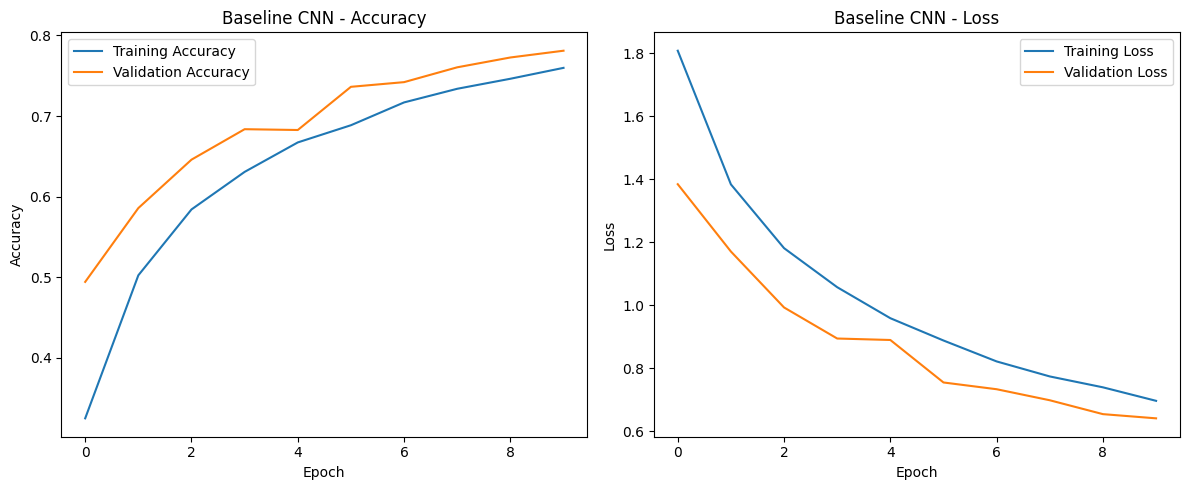

In [6]:
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(baseline_cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(baseline_cnn_history.history['loss'], label='Training Loss')
plt.plot(baseline_cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Baseline CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
from tensorflow.keras.layers import Conv2D, MaxPool2D

# Build Regularized CNN for CIFAR-10 (32x32x3 images)
regularized_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001), input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    
    # Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    
    # Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    Conv2D(128, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

regularized_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

regularized_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the regularized model using the same CIFAR-10 data
regularized_history = regularized_cnn.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.2035 - loss: 2.3122 - val_accuracy: 0.4096 - val_loss: 1.6924
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4072 - loss: 1.6877 - val_accuracy: 0.4935 - val_loss: 1.4885
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4745 - loss: 1.5505 - val_accuracy: 0.5527 - val_loss: 1.3584
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5178 - loss: 1.4657 - val_accuracy: 0.5708 - val_loss: 1.3167
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5368 - loss: 1.4224 - val_accuracy: 0.5893 - val_loss: 1.2780
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5672 - loss: 1.3651 - val_accuracy: 0.6161 - val_loss: 1.2301
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5800 - loss: 1.3329 - val_accuracy: 0.6216 - val_loss: 1.2082
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5984 - loss: 1.2926 - val_acc

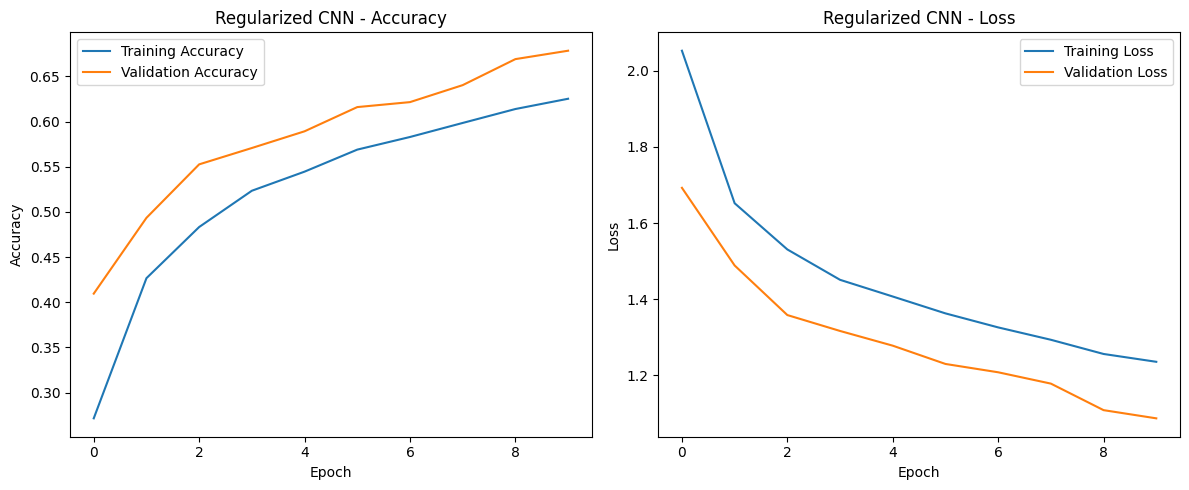

In [13]:
# Change reg_cnn_history → regularized_history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(regularized_history.history['accuracy'], label='Training Accuracy')
plt.plot(regularized_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Regularized CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(regularized_history.history['loss'], label='Training Loss')
plt.plot(regularized_history.history['val_loss'], label='Validation Loss')
plt.title('Regularized CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# PART III

In [21]:
# ===== PART III: Keras Tuner - Hyperparameter Optimization =====
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    
    # Tune number of Conv2D blocks (2 or 3)
    for i in range(hp.Int('conv_blocks', 2, 3)):
        model.add(Conv2D(
            filters=hp.Choice(f'filters_{i}', values=[32, 64, 128]),
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            input_shape=(32, 32, 3) if i == 0 else None
        ))
        model.add(MaxPool2D((2, 2)))
        model.add(Dropout(hp.Float(f'conv_dropout_{i}', 0.1, 0.4, step=0.1)))
    
    model.add(Flatten())
    
    # Tune Dense layer units
    model.add(Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dense_dropout', 0.3, 0.6, step=0.1)))
    
    model.add(Dense(10, activation='softmax'))
    
    # Tune learning rate
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='cifar10_cnn'
)

# Show search space
tuner.search_space_summary()

# Run the search (this will take ~10-20 minutes)
tuner.search(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Trial 10 Complete [00h 00m 43s]
val_accuracy: 0.6978999972343445

Best val_accuracy So Far: 0.7199000120162964
Total elapsed time: 00h 09m 33s


In [22]:
# Get the best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

print("🏆 Best Hyperparameters Found:")
print(f"  Conv blocks:    {best_hp.get('conv_blocks')}")
print(f"  Filters block 0: {best_hp.get('filters_0')}")
print(f"  Filters block 1: {best_hp.get('filters_1')}")
if best_hp.get('conv_blocks') == 3:
    print(f"  Filters block 2: {best_hp.get('filters_2')}")
print(f"  Conv dropout 0: {best_hp.get('conv_dropout_0')}")
print(f"  Conv dropout 1: {best_hp.get('conv_dropout_1')}")
if best_hp.get('conv_blocks') == 3:
    print(f"  Conv dropout 2: {best_hp.get('conv_dropout_2')}")
print(f"  Dense units:    {best_hp.get('dense_units')}")
print(f"  Dense dropout:  {best_hp.get('dense_dropout')}")
print(f"  Learning rate:  {best_hp.get('learning_rate')}")

# Show top 3 trials
tuner.results_summary(num_trials=3)

🏆 Best Hyperparameters Found:
  Conv blocks:    2
  Filters block 0: 128
  Filters block 1: 128
  Conv dropout 0: 0.4
  Conv dropout 1: 0.2
  Dense units:    128
  Dense dropout:  0.4
  Learning rate:  0.001
Results summary
Results in tuner_results/cifar10_cnn
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
conv_blocks: 2
filters_0: 128
conv_dropout_0: 0.4
filters_1: 128
conv_dropout_1: 0.2
dense_units: 128
dense_dropout: 0.4
learning_rate: 0.001
filters_2: 64
conv_dropout_2: 0.2
Score: 0.7199000120162964

Trial 04 summary
Hyperparameters:
conv_blocks: 2
filters_0: 64
conv_dropout_0: 0.4
filters_1: 32
conv_dropout_1: 0.30000000000000004
dense_units: 256
dense_dropout: 0.5
learning_rate: 0.001
filters_2: 64
conv_dropout_2: 0.4
Score: 0.7038999795913696

Trial 05 summary
Hyperparameters:
conv_blocks: 2
filters_0: 128
conv_dropout_0: 0.1
filters_1: 128
conv_dropout_1: 0.1
dense_units: 64
dense_dropout: 0.5
learning_rate: 0.001
filte

In [23]:
# Build the best model
best_model = tuner.hypermodel.build(best_hp)

# Train it for more epochs with callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

best_history = best_model.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.2532 - loss: 2.0149 - val_accuracy: 0.5058 - val_loss: 1.4016
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4543 - loss: 1.5028 - val_accuracy: 0.5768 - val_loss: 1.2027
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5120 - loss: 1.3461 - val_accuracy: 0.5947 - val_loss: 1.1360
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5436 - loss: 1.2676 - val_accuracy: 0.6187 - val_loss: 1.1122
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5695 - loss: 1.1975 - val_accuracy: 0.6415 - val_loss: 1.0329
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5770 - loss: 1.1684 - val_accuracy: 0.6638 - val_loss: 0.9831
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5996 - loss: 1.1123 - val_accuracy: 0.6625 - val_loss: 0.9661
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6103 - loss: 1.0881 - val_acc

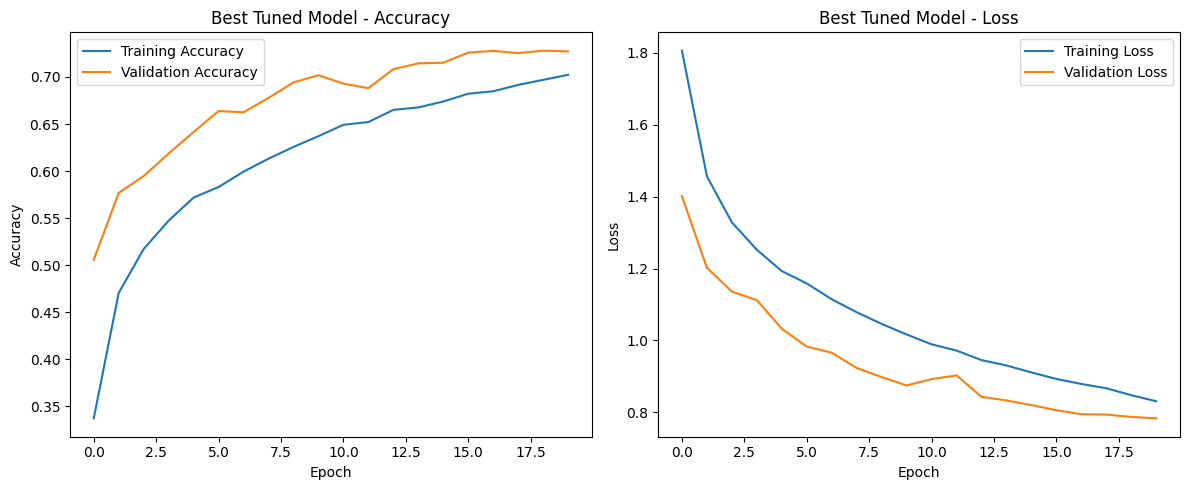

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Best Tuned Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title('Best Tuned Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()